# **Land mines**

### **Pendahuluan**

Dataset yang saya pilih adalah dataset berjudul "Land mines". Dataset ini berisi data dari sensor yang mendeteksi jenis-jenis ranjau darat yang berbeda berdasarkan beberapa fitur input, diantaranya ada: tegangan sensor (V), tinggi sensor dari tanah (H), dan jenis tanah (S). Masalah yang ingin diselesaikan adalah klasifikasi jenis ranjau (M) berdasarkan fitur-fitur tersebut.

Penjelasan Kolom:
V (Voltage): Tegangan output dari sensor FLC.
H (Height): Tinggi sensor dari tanah.
S (Soil Type): Jenis tanah, terdiri dari 6 tipe berbeda.
M (Mine Type): Jenis ranjau, terdiri dari 5 kelas yang berbeda

Sebelum melakukan training dan testing, saya mengolah data terlebih dahulu.

## **1. Loading Dataset**

#### Install Required Library

In [1]:
!pip install ucimlrepo

#### Import Libraries

In [2]:
import pandas as pd  # For tabular data processing
import seaborn as sns  # For data visualization
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting

#### Download dataset from UCI Machine Learning Repository

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
land_mines = fetch_ucirepo(id=763)

# Convert the dataset into a Pandas DataFrame
df = pd.DataFrame(data=land_mines.data.features, columns=land_mines.data.features.columns)
# Add the target variable
df['MineType'] = land_mines.data.targets

print(land_mines.metadata)  # Shows dataset description
print(land_mines.variables)  # Lists all variables

{'uci_id': 763, 'name': 'Land Mines', 'repository_url': 'https://archive.ics.uci.edu/dataset/763/land+mines-1', 'data_url': 'https://archive.ics.uci.edu/static/public/763/data.csv', 'abstract': 'Detection of mines buried in the ground is very important in terms of safety of life and property. Many different methods have been used in this regard; however, it has not yet been possible to achieve 100% success. Mine detection process consists of sensor design, data analysis and decision algorithm phases. The magnetic anomaly method works according to the principle of measuring the anomalies resulting from the object in the magnetic field that disturbs the structure of it, the magnetic field, and the data obtained at this point are used to determine the conditions such as motion and position. The determination of parameters such as position, depth or direction of motion using magnetic anomaly has been carried out since 1970.', 'area': 'Engineering', 'tasks': ['Classification', 'Clustering']

## **2. Exploratory Data Analysis**

In [4]:
df.head()

,V,H,S,MineType
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


2.1 Statistik Deskriptif

In [5]:
# Statistik deskriptif dari dataset
df.describe()

,V,H,S,MineType
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


🔎 Analisis:

1. Volt (tegangan sensor): Nilai berkisar dari 0.19 hingga 1.00, rata-rata di 0.43. Artinya sensor bekerja dalam rentang tegangan yang cukup stabil.
2. High (tinggi sensor): Tersebar dari 0.00 hingga 1.00, dengan median di 0.54. Ini menandakan sebagian besar data memiliki tinggi sensor mendekati setengah maksimum.
3. SoilType: Mean mendekati 0.50, menandakan sebaran jenis tanah cukup merata. Nilai-nilai ini direpresentasikan dalam bentuk numerik kontinu, walaupun sebenarnya ini kategori.
4. MineType: Ada 5 kelas ranjau, dengan mean di 2.95 dan standar deviasi 1.42. Distribusi terlihat relatif seimbang jika melihat quartile dan range.

2.2 Informasi Data dan Cek Missing Values

In [6]:
# Info tipe data dan cek null
df.info()
print("\nJumlah Missing Values Tiap Kolom:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   V         338 non-null    float64
 1   H         338 non-null    float64
 2   S         338 non-null    float64
 3   MineType  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB

Jumlah Missing Values Tiap Kolom:
V           0
H           0
S           0
MineType    0
dtype: int64


📄 Output:

- Dataset berisi 338 baris dan 4 kolom.
- Semua kolom memiliki 338 data non-null, artinya tidak ada missing values.
- Tipe data: Volt, High, dan SoilType adalah float64, sedangkan MineType bertipe int64.

✅ Kesimpulan: Data bersih dan siap digunakan tanpa perlu imputasi atau cleaning tambahan.

2.3 Jumlah Data per Kelas (Distribusi Target)

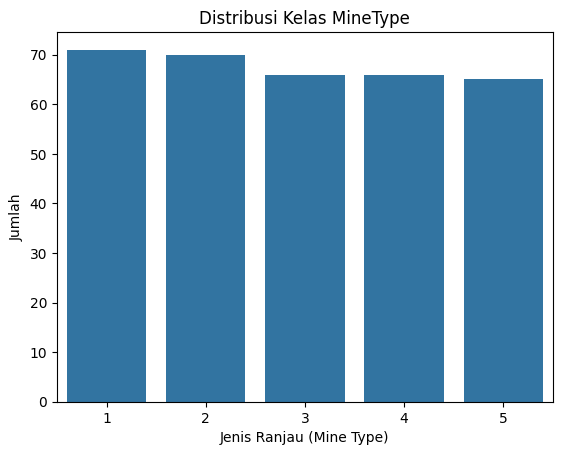

MineType
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


In [7]:
# Cek distribusi kelas pada kolom target (MineType)
sns.countplot(x='MineType', data=df)
plt.title("Distribusi Kelas MineType")
plt.xlabel("Jenis Ranjau (Mine Type)")
plt.ylabel("Jumlah")
plt.show()

print(df['MineType'].value_counts())

📌 Analisis:

- Distribusi kelas target cukup seimbang. Semua kelas memiliki jumlah data yang hampir sama (selisih hanya beberapa).
- Ini merupakan kondisi ideal untuk klasifikasi karena tidak terjadi class imbalance yang signifikan.
- Dengan distribusi yang merata, model tidak akan bias terhadap satu kelas saja.

2.4 Deteksi Outlier

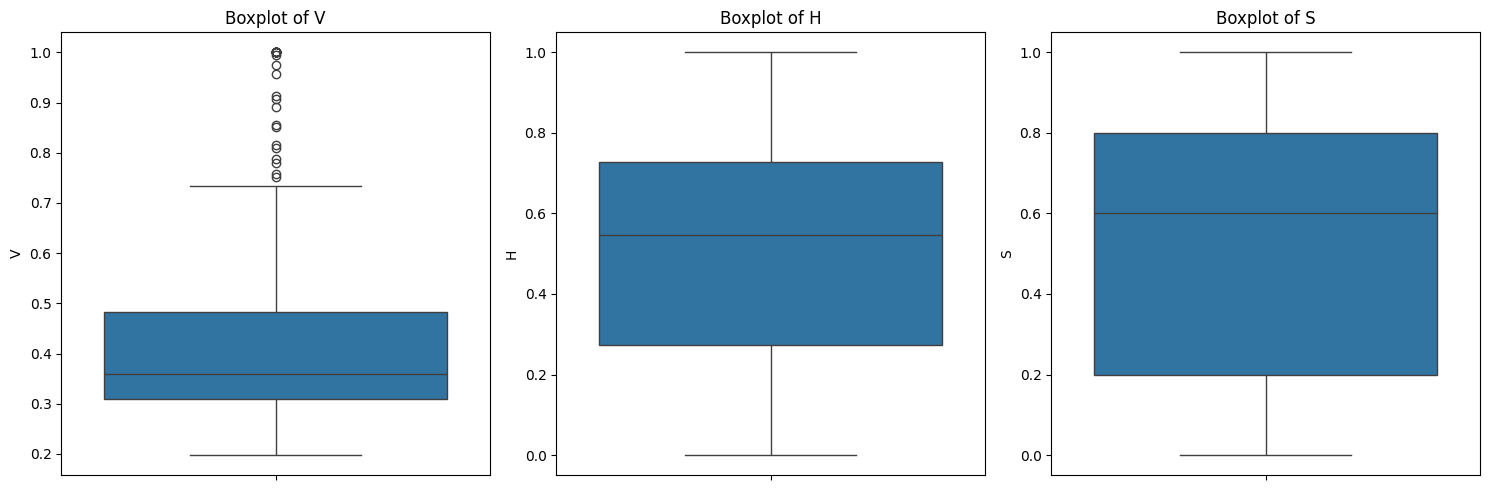

In [8]:
# Boxplot untuk mendeteksi outlier pada setiap fitur numerik
plt.figure(figsize=(15, 5))

# Corrected column names to match the DataFrame
for i, col in enumerate(['V', 'H', 'S']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

🔎 Analisis:
- Volt: Beberapa titik ekstrim di atas 0.9 tampak sebagai potensi outlier, tapi tidak ekstrem
- High: Nilai 0 menunjukkan sensor berada tepat di tanah. Jika ini valid (misal untuk baseline), maka bukan outlier. Namun jika error, perlu klarifikasi.
- SoilType: Karena nilainya diskrit (kategori numerik), meskipun divisualisasikan dengan boxplot, ini tidak menunjukkan outlier nyata.

2.5 Korelasi Antar Fitur (Heatmap)

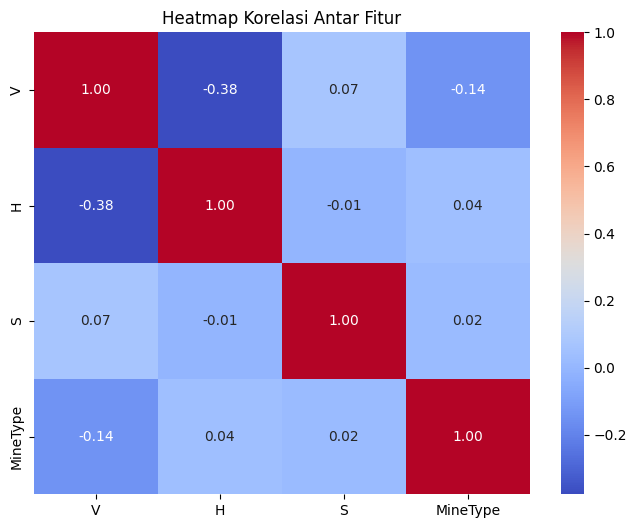

In [9]:
# Korelasi antar fitur
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

🔎 Analisis:
- Tidak ada korelasi kuat antar fitur.
- Korelasi tertinggi adalah antara SoilType dan MineType (0.14), masih tergolong lemah.
- Ini menandakan bahwa hubungan antar fitur tidak linear — pendekatan non-linear seperti Decision Tree, Random Forest, atau Neural Network lebih cocok.



2.6 Sebaran Fitur terhadap Kelas (Target)

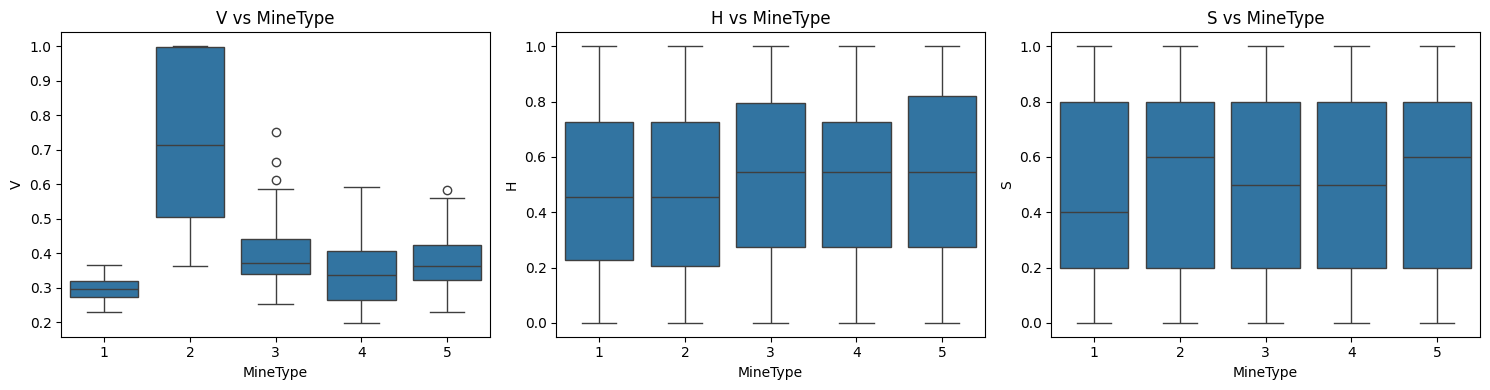

In [10]:
# Boxplot tiap fitur terhadap kelas target
plt.figure(figsize=(15, 4))

for i, col in enumerate(['V', 'H', 'S']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='MineType', y=col, data=df)
    plt.title(f'{col} vs MineType')

plt.tight_layout()
plt.show()


🔎 Analisis:
- Volt: Kelas 2 cenderung punya tegangan tinggi, sementara kelas 1 lebih rendah.
- High: Tinggi sensor tidak berbeda drastis antar kelas. Namun kelas 2 sedikit lebih rendah rata-ratanya dibanding lainnya.
- SoilType: Distribusi sedikit berbeda, terutama kelas 3 dan 4, namun cenderung overlap(tumpang tindih)

 2.7 Pairplot antar Fitur

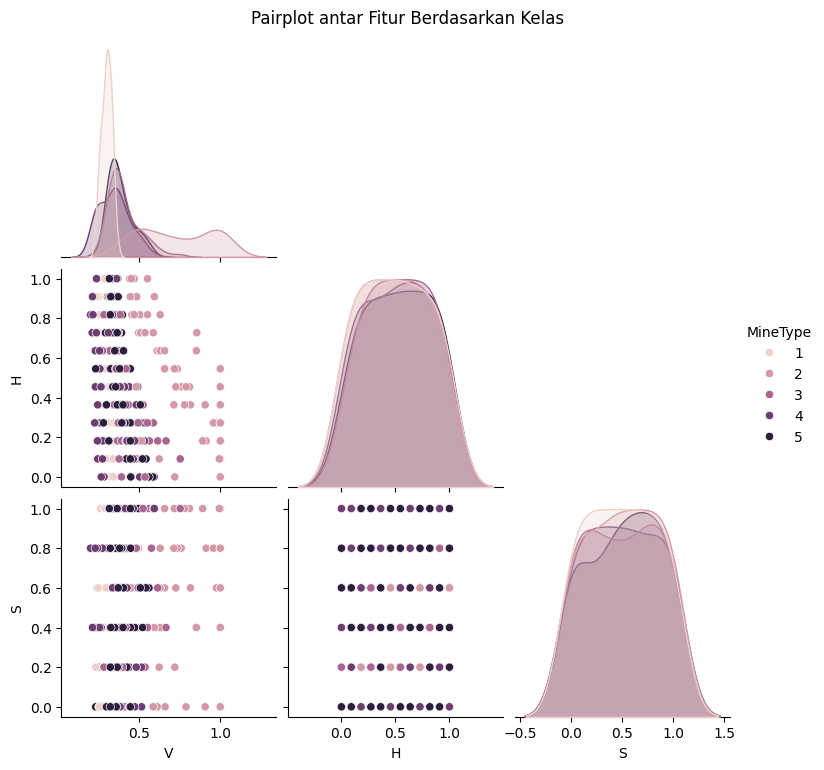

In [11]:
import seaborn as sns

sns.pairplot(df, hue="MineType", diag_kind="kde", corner=True)
plt.suptitle("Pairplot antar Fitur Berdasarkan Kelas", y=1.02)
plt.show()


🔎 Analisis:
- Kombinasi fitur Volt vs High memperlihatkan separability cukup jelas antar kelas 1–2 vs lainnya.
- SoilType cenderung tumpang tindih (overlap), namun bila digabung dengan Volt bisa membantu pembeda.
- Data terlihat membentuk klaster tidak linear → mengonfirmasi bahwa linear classifier mungkin tidak ideal.

## **3. Data Preprocessing**

3.1 Normalisasi/Standarisasi Fitur

In [12]:
df.describe()

,V,H,S,MineType
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


🔎 Analisis:

Nilai fitur Volt, High, dan SoilType semuanya sudah berada dalam rentang 0–1. Maka tidak perlu normalisasi ulang

3.2 Encoding Target

In [13]:
df['MineType'].unique()

array([1, 2, 3, 4, 5])

🔎 Analisis:

Target MineType sudah dalam bentuk numerik integer (1–5), jadi tidak perlu encoding tambahan.

3.3 Cek dan Tangani Outlier

In [14]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

df_clean = df.copy()
for col in ['V', 'H']:
    df_clean = remove_outliers_iqr(df_clean, col)


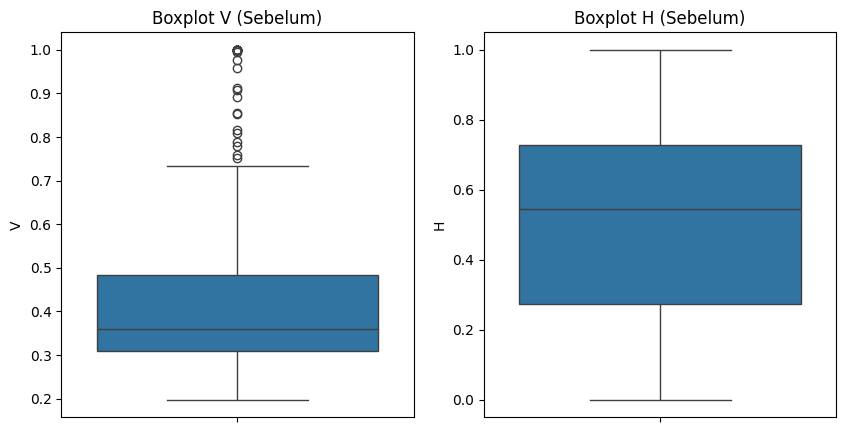

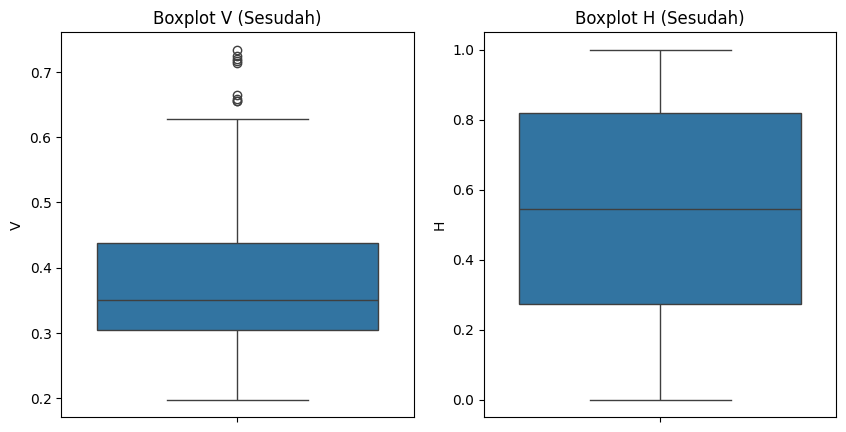

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot sebelum penanganan outlier
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['V'])
plt.title('Boxplot V (Sebelum)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['H'])
plt.title('Boxplot H (Sebelum)')
plt.show()

# Boxplot sesudah penanganan outlier
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['V'])
plt.title('Boxplot V (Sesudah)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['H'])
plt.title('Boxplot H (Sesudah)')
plt.show()

3.4 Pisahkan Fitur dan Label

In [16]:
X = df_clean.drop('MineType', axis=1)
y = df_clean['MineType']

3.5 Split Data Training dan Test

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Menampilkan shape data
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (244, 3)
Shape X_test: (62, 3)
Shape y_train: (244,)
Shape y_test: (62,)


Analisis:

Digunakan stratify=y agar distribusi kelas tetap seimbang di train/test split.

3.6 Penggunaan K-fold Cross validation untuk data Training

In [18]:
# K-Fold Processing

num_of_fold = 5
num_per_fold = len(X_train) // num_of_fold

fold_split_index = []
for i in range(num_of_fold):
  start_index = num_per_fold * i
  end_index = min(start_index + num_per_fold, len(X_train))
  val_index = np.arange(start_index, end_index)

  mask = ~np.isin(np.arange(len(X_train)), val_index)
  train_index = np.arange(len(X_train))[mask]

  fold_split_index.append((train_index, val_index))

for i, (train_index, val_index) in enumerate(fold_split_index):
    print(f"Fold {i+1}:")
    print(f"  Validation Data: {len(val_index)}")
    print(f"  Training Data: {len(train_index)}\n")

Fold 1:
  Validation Data: 48
  Training Data: 196

Fold 2:
  Validation Data: 48
  Training Data: 196

Fold 3:
  Validation Data: 48
  Training Data: 196

Fold 4:
  Validation Data: 48
  Training Data: 196

Fold 5:
  Validation Data: 48
  Training Data: 196



### **4. Modeling dan Evaluasi Multi-Model** sampe sini


📌 Model: Logistic Regression
Accuracy (Cross-Validation): 0.13333333333333336
              precision    recall  f1-score   support

           1       0.16      0.31      0.21        71
           2       0.56      0.26      0.36        38
           3       0.00      0.00      0.00        44
           4       0.00      0.00      0.00        44
           5       0.00      0.00      0.00        43

    accuracy                           0.13       240
   macro avg       0.14      0.11      0.11       240
weighted avg       0.14      0.13      0.12       240



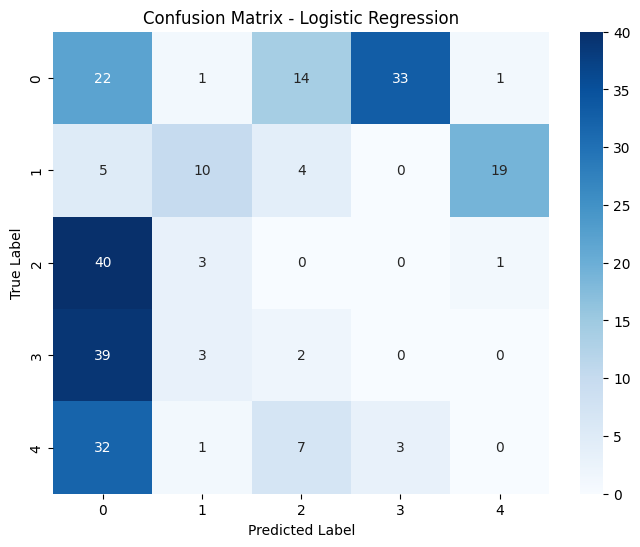

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ### Model 1: Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
scores_lr = []
all_y_true_lr = []
all_y_pred_lr = []

for train_index, val_index in fold_split_index:
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model_lr.fit(X_train, y_train)
    y_pred = model_lr.predict(X_val)

    scores_lr.append(accuracy_score(y_val, y_pred))
    all_y_true_lr.extend(y_val)
    all_y_pred_lr.extend(y_pred)

cm_lr = confusion_matrix(all_y_true_lr, all_y_pred_lr)

print(f"\n📌 Model: Logistic Regression")
print(f"Accuracy (Cross-Validation): {np.mean(scores_lr)}")
print(classification_report(all_y_true_lr, all_y_pred_lr))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


📌 Model: Decision Tree
Accuracy (Cross-Validation): 0.2875
              precision    recall  f1-score   support

           1       0.60      0.49      0.54        71
           2       0.60      0.55      0.58        38
           3       0.12      0.11      0.12        44
           4       0.10      0.11      0.11        44
           5       0.05      0.07      0.06        43

    accuracy                           0.29       240
   macro avg       0.30      0.27      0.28       240
weighted avg       0.32      0.29      0.30       240



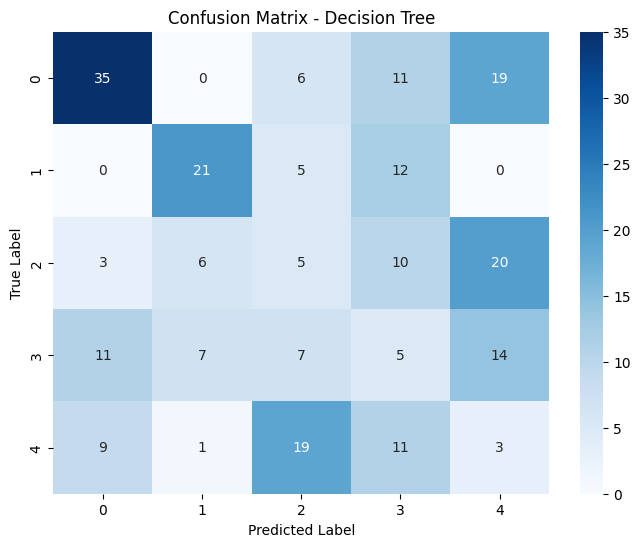

In [20]:
from sklearn.tree import DecisionTreeClassifier

# ### Model 3: Decision Tree
model_dt = DecisionTreeClassifier()
scores_dt = []
all_y_true_dt = []
all_y_pred_dt = []

for train_index, val_index in fold_split_index:
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model_dt.fit(X_train, y_train)
    y_pred = model_dt.predict(X_val)

    scores_dt.append(accuracy_score(y_val, y_pred))
    all_y_true_dt.extend(y_val)
    all_y_pred_dt.extend(y_pred)

cm_dt = confusion_matrix(all_y_true_dt, all_y_pred_dt)

print(f"\n📌 Model: Decision Tree")
print(f"Accuracy (Cross-Validation): {np.mean(scores_dt)}")
print(classification_report(all_y_true_dt, all_y_pred_dt))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



📌 Model: Random Forest
Accuracy (Cross-Validation): 0.3125
              precision    recall  f1-score   support

           1       0.61      0.65      0.63        71
           2       0.74      0.66      0.69        38
           3       0.05      0.05      0.05        44
           4       0.05      0.05      0.05        44
           5       0.00      0.00      0.00        43

    accuracy                           0.31       240
   macro avg       0.29      0.28      0.28       240
weighted avg       0.31      0.31      0.31       240



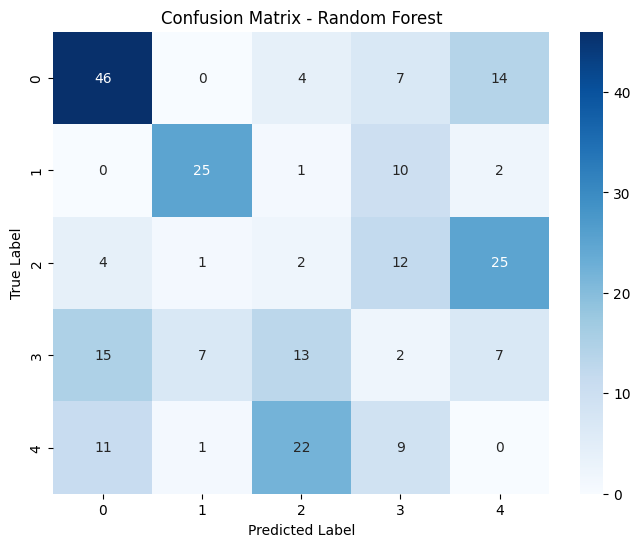

In [21]:
from sklearn.ensemble import RandomForestClassifier
# ### Model 4: Random Forest
model_rf = RandomForestClassifier()
scores_rf = []
all_y_true_rf = []
all_y_pred_rf = []

for train_index, val_index in fold_split_index:
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model_rf.fit(X_train, y_train)
    y_pred = model_rf.predict(X_val)

    scores_rf.append(accuracy_score(y_val, y_pred))
    all_y_true_rf.extend(y_val)
    all_y_pred_rf.extend(y_pred)

cm_rf = confusion_matrix(all_y_true_rf, all_y_pred_rf)

print(f"\n📌 Model: Random Forest")
print(f"Accuracy (Cross-Validation): {np.mean(scores_rf)}")
print(classification_report(all_y_true_rf, all_y_pred_rf))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


📌 Model: SVM
Accuracy (Cross-Validation): 0.15
              precision    recall  f1-score   support

           1       0.15      0.24      0.19        71
           2       0.86      0.50      0.63        38
           3       0.00      0.00      0.00        44
           4       0.00      0.00      0.00        44
           5       0.00      0.00      0.00        43

    accuracy                           0.15       240
   macro avg       0.20      0.15      0.16       240
weighted avg       0.18      0.15      0.16       240



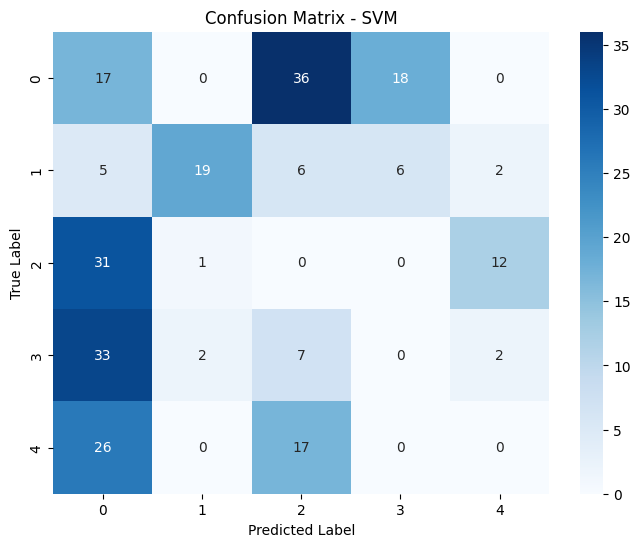

In [22]:
from sklearn.svm import SVC
# ### Model 5: SVM
model_svm = SVC()
scores_svm = []
all_y_true_svm = []
all_y_pred_svm = []

for train_index, val_index in fold_split_index:
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model_svm.fit(X_train, y_train)
    y_pred = model_svm.predict(X_val)

    scores_svm.append(accuracy_score(y_val, y_pred))
    all_y_true_svm.extend(y_val)
    all_y_pred_svm.extend(y_pred)

cm_svm = confusion_matrix(all_y_true_svm, all_y_pred_svm)

print(f"\n📌 Model: SVM")
print(f"Accuracy (Cross-Validation): {np.mean(scores_svm)}")
print(classification_report(all_y_true_svm, all_y_pred_svm))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


📌 Model: Gradient Boosting
Accuracy (Cross-Validation): 0.2958333333333333
              precision    recall  f1-score   support

           1       0.60      0.61      0.60        71
           2       0.68      0.66      0.67        38
           3       0.00      0.00      0.00        44
           4       0.09      0.07      0.08        44
           5       0.00      0.00      0.00        43

    accuracy                           0.30       240
   macro avg       0.27      0.27      0.27       240
weighted avg       0.30      0.30      0.30       240



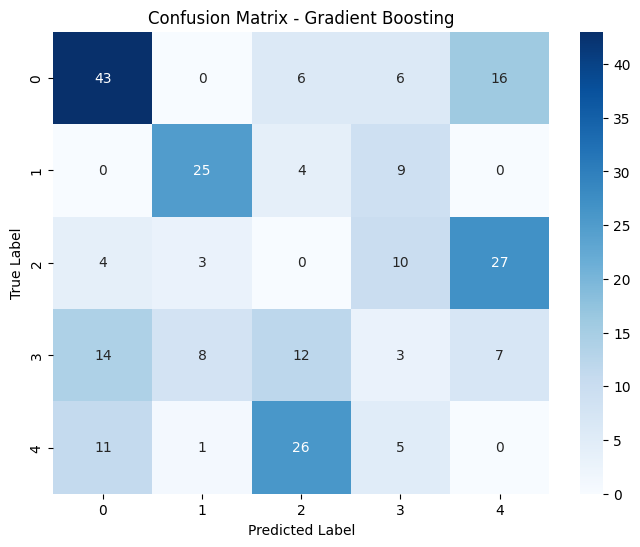

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

# ### Model 6: Gradient Boosting
model_gb = GradientBoostingClassifier()
scores_gb = []
all_y_true_gb = []
all_y_pred_gb = []

for train_index, val_index in fold_split_index:
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model_gb.fit(X_train, y_train)
    y_pred = model_gb.predict(X_val)

    scores_gb.append(accuracy_score(y_val, y_pred))
    all_y_true_gb.extend(y_val)
    all_y_pred_gb.extend(y_pred)

cm_gb = confusion_matrix(all_y_true_gb, all_y_pred_gb)

print(f"\n📌 Model: Gradient Boosting")
print(f"Accuracy (Cross-Validation): {np.mean(scores_gb)}")
print(classification_report(all_y_true_gb, all_y_pred_gb))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### **5. Hyperparameter Tuning** sampe sini

---

Untuk mengoptimalkan performa model, dilakukan proses hyperparameter tuning menggunakan GridSearchCV dengan skema Stratified K-Fold Cross Validation sebanyak 5 fold. Pemilihan StratifiedKFold bertujuan agar distribusi kelas pada setiap fold tetap seimbang, sehingga evaluasi model menjadi lebih adil dan akurat, terutama pada kasus klasifikasi dengan jumlah data per kelas yang tidak identik.

Proses tuning dilakukan pada model Random Forest Classifier dengan eksplorasi terhadap beberapa parameter penting, yaitu:

- n_estimators: jumlah pohon dalam hutan,
- max_depth: kedalaman maksimum pohon,
- min_samples_split: jumlah minimum sampel untuk membagi sebuah node.

In [24]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 2. Definisikan parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
}

# 3. Buat model dasar Random Forest
model_rf = RandomForestClassifier(random_state=42)

# 4. Gunakan StratifiedKFold untuk cross-validation yang seimbang
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Hyperparameter tuning dengan GridSearchCV
grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1
)

# 6. Fit model dengan data training
grid_search.fit(X_train, y_train)

# 7. Evaluasi model terbaik
print("🔍 Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Test Accuracy: {accuracy:.4f}")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

🔍 Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
✅ Test Accuracy: 0.6452

📊 Classification Report:
               precision    recall  f1-score   support

           1       0.58      0.93      0.72        15
           2       1.00      0.88      0.93         8
           3       0.53      0.69      0.60        13
           4       0.75      0.46      0.57        13
           5       0.67      0.31      0.42        13

    accuracy                           0.65        62
   macro avg       0.71      0.65      0.65        62
weighted avg       0.68      0.65      0.63        62



In [25]:
# 1. Definisikan parameter grid untuk Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

# 2. Buat model dasar Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)

# 3. Gunakan StratifiedKFold untuk cross-validation yang seimbang
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Hyperparameter tuning dengan GridSearchCV untuk Decision Tree
grid_search_dt = GridSearchCV(
    estimator=model_dt,
    param_grid=param_grid_dt,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1
)

# 5. Fit model dengan data training
grid_search_dt.fit(X_train, y_train)

# 6. Evaluasi model terbaik untuk Decision Tree
print("🔍 Best Parameters for Decision Tree:", grid_search_dt.best_params_)

best_model_dt = grid_search_dt.best_estimator_

# 7. Prediksi dan evaluasi menggunakan data test (X_test, y_test)
y_pred_dt = best_model_dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"✅ Test Accuracy (Decision Tree): {dt_accuracy:.4f}")
print("\n📊 Classification Report (Decision Tree):\n", classification_report(y_test, y_pred_dt))

🔍 Best Parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
✅ Test Accuracy (Decision Tree): 0.5484

📊 Classification Report (Decision Tree):
               precision    recall  f1-score   support

           1       0.80      0.53      0.64        15
           2       1.00      0.75      0.86         8
           3       0.37      0.77      0.50        13
           4       0.56      0.38      0.45        13
           5       0.50      0.38      0.43        13

    accuracy                           0.55        62
   macro avg       0.65      0.56      0.58        62
weighted avg       0.62      0.55      0.56        62



### **6. Final model** sampe sini

In [ ]:

# 1. Latih model dengan data training menggunakan hyperparameter terbaik
final_model = grid_search.best_estimator_

# 2. Evaluasi model pada data test
y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"✅ Test Accuracy: {test_accuracy:.4f}")
print("\n📊 Final Classification Report:\n", classification_report(y_test, y_test_pred))


✅ Test Accuracy: 0.6452

📊 Final Classification Report:
               precision    recall  f1-score   support

           1       0.58      0.93      0.72        15
           2       1.00      0.88      0.93         8
           3       0.53      0.69      0.60        13
           4       0.75      0.46      0.57        13
           5       0.67      0.31      0.42        13

    accuracy                           0.65        62
   macro avg       0.71      0.65      0.65        62
weighted avg       0.68      0.65      0.63        62

